mean:-0.004
std: 1.019
1


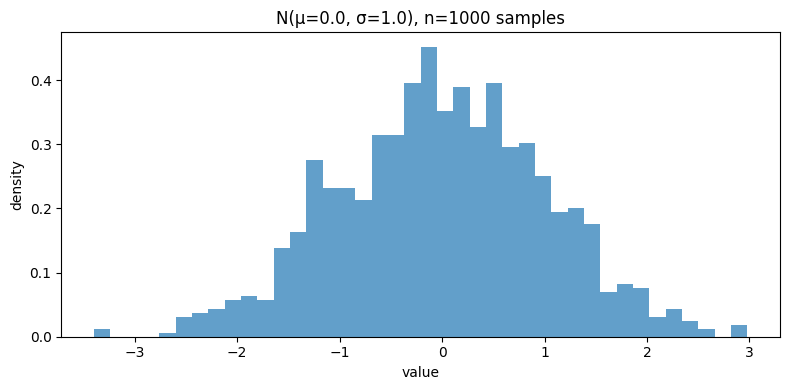

In [11]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

#creating a random key
key = jax.random.PRNGKey(100) 

""" creating seed for reproducability """

#mean of distribution
mu = 0.0 

#setting standard deviation
sigma = 1.0

#setting the number of samples that are being chosen
n = 1000

samples = jax.random.normal(key, shape=(n,)) * sigma + mu
print(f"mean:{jnp.mean(samples):.3f}")
print(f"std: {jnp.std(samples):.3f}")
print(samples.ndim)

plt.figure(figsize=(8,4))
plt.hist(samples, bins = 40, density = True, alpha=0.7)
plt.xlabel("value")
plt.ylabel("density")
plt.title(f"N(μ={mu}, σ={sigma}), n={n} samples")
plt.tight_layout()
plt.show()



to generate the normal distibution you have to multiply it by sigma and mu to get more outputs
- mathmetically sound technique to multiply sigma and mu


bins: divides the histogram into 40 vertical bars
density: normalizes the histogram so the area is 1
alpha: amkes the bars 70% opaque 

1
(2,)
2
(1000, 2)


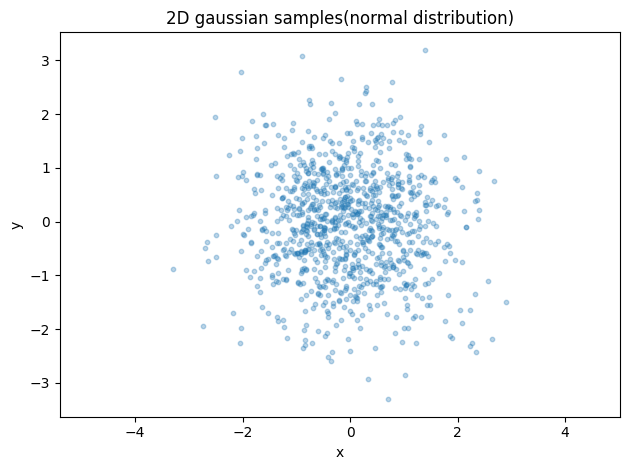

In [13]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

key = jax.random.PRNGKey(100)

#mu became an array so now we have one center value per dimension
mu = jnp.array([0.0, 0.0])
print(mu.ndim)
print(mu.shape)

#covariance matrix
cov = jnp.array ([[1, 0],
                  [0, 1]])

print(cov.ndim)

#shape=(1000,) gives 1000 samples, each a 2D point
samples = jax.random.multivariate_normal(key, mean = mu, cov = cov, shape=(1000,))

print(samples.shape)

#split into x and y columns
x = samples[:,0]
y = samples[:,1]

plt.figure
plt.scatter(x, y, alpha=0.3, s=10)
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D gaussian samples(normal distribution)")
plt.axis("equal")
plt.tight_layout()
plt.show()



covariance is used to describe relationships for example, height and weight or position and momentum 

- co variance can capture the spread and the relationship between the dimension aka what sigma can't do


[[ spread of x,        x-y relationship ],
 [ x-y relationship,   spread of y      ]]

 cov = jnp.array([[var_x,  corr ],
                 [corr,   var_y]])

                 var_x/y = sigma sq
                 corr = (-) independent move oppositley 
                 corr = (+) dependent and move together

In [14]:
import jax.numpy as jnp

# --- vectors ---
v = jnp.array([1.0, 2.0, 3.0])
print(f"vector: {v}")

# --- matrix × vector (the @ operator) ---
A = jnp.array([[2.0, 0.0, 0.0],
               [0.0, 3.0, 0.0],
               [0.0, 0.0, 1.0]])
result = A @ v
print(f"A @ v:  {result}")       # [2, 6, 3]

# --- the three norms ---
print(f"L2 norm: {jnp.linalg.norm(v):.3f}")            # √(1+4+9) = √14 ≈ 3.742
print(f"L1 norm: {jnp.linalg.norm(v, ord=1):.3f}")     # 1+2+3 = 6
print(f"L∞ norm: {jnp.linalg.norm(v, ord=jnp.inf):.3f}") # max = 3

# --- norm-based error metric ---
v_true   = jnp.array([1.0, 0.0, 0.0, 0.0])   # true quantum state
v_approx = jnp.array([0.9, 0.1, 0.05, 0.0])  # sketch approximation

absolute_error = jnp.linalg.norm(v_true - v_approx)
relative_error = absolute_error / jnp.linalg.norm(v_true)

print(f"absolute error: {absolute_error:.4f}")
print(f"relative error: {relative_error:.4f}")   # as a fraction — 0.01 = 1% off

vector: [1. 2. 3.]
A @ v:  [2. 6. 3.]
L2 norm: 3.742
L1 norm: 6.000
L∞ norm: 3.000
absolute error: 0.1500
relative error: 0.1500
